# Was macht einen Top-Anime aus?

**Datensatz:** MyAnimeList 2020 -- 17.562 Anime-Eintraege.

Zwei zusammengehoerige Analysen:
1. **Regression** -- Welche Eigenschaften eines Anime erklaeren seinen Score (1.85-9.19)?
2. **Top-Analyse** -- Was unterscheidet Top-Animes (Score >= 8) von der Masse? Deskriptiv + binaerer Klassifikator.

*Empfehlungssystem: siehe `02_empfehlung.ipynb`*

## 1. Datensatz & Bereinigung

`Unknown`-Strings werden durch `NaN` ersetzt, danach werden numerische Spalten (Score, Episodes, Ranked) korrekt konvertiert.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/anime.csv')
df.sample(5)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
12105,33849,Nekoronde ID,Unknown,Comedy,Unknown,ねころんでID,Special,4,"May 14, 2016",Unknown,Nippon Television Network,Unknown,Unknown,Original,16 sec. per ep.,G - All Ages,11099.0,16198,127,0,8,53,2,29,35,4.0,Unknown,Unknown,2.0,2.0,6.0,6.0,7.0,2.0,10.0
13890,36821,Machibouke,Unknown,"Music, Kids",Unknown,待ちぼうけ,Music,1,"Aug 16, 1973",Unknown,NHK,Unknown,Unknown,Original,2 min.,G - All Ages,15346.0,16581,111,0,6,63,3,15,24,5.0,Unknown,2.0,1.0,3.0,9.0,7.0,7.0,3.0,9.0
13225,35708,Afureko! AR,Unknown,Unknown,Unknown,あふれこ! AR,ONA,3,"Jan 31, 2012",Unknown,Unknown,Unknown,Unknown,Unknown,2 min. per ep.,G - All Ages,13217.0,14406,230,0,13,122,4,28,63,7.0,Unknown,Unknown,10.0,9.0,22.0,8.0,12.0,11.0,9.0
7289,15607,Ai no Wakakusa Monogatari Specials,6.35,"Drama, Historical, Slice of Life",Unknown,愛の若草物語,Special,2,2001,Unknown,BS Fuji,Unknown,Nippon Animation,Unknown,45 min. per ep.,G - All Ages,6638.0,11921,541,0,15,241,11,58,216,11.0,6.0,20.0,17.0,44.0,24.0,11.0,1.0,1.0,6.0
5181,7870,Baka to Test to Shoukanjuu Specials,7.33,"Magic, Comedy, School",Unknown,バカとテストと召喚獣 映像特典,Special,6,"Apr 23, 2010 to Sep 22, 2010",Unknown,Unknown,Funimation,SILVER LINK.,Light novel,4 min. per ep.,PG-13 - Teens 13 or older,2204.0,2427,43497,44,802,31667,753,444,9831,1903.0,2484.0,4696.0,5865.0,3042.0,1354.0,324.0,162.0,72.0,54.0


### Cleanup: "Unknown" → NaN + numerische Konvertierung

In [2]:
# "Unknown"-Strings durch NaN ersetzen und numerische Spalten konvertieren
df = df.replace('Unknown', np.nan)

df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')
df['Ranked'] = pd.to_numeric(df['Ranked'], errors='coerce')

for col in [f'Score-{i}' for i in range(1, 11)]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Anime mit Score: {df['Score'].notna().sum()}  /  ohne: {df['Score'].isna().sum()}")

Anime mit Score: 12421  /  ohne: 5141


## 2. Explorative Datenanalyse (EDA)

Nur Anime mit vorhandenem Score werden für die Analyse verwendet (12.421 von 17.562).  
Zielvariable: **Score** (kontinuierlich, 1.85–9.19, Mittelwert ~6.5).

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_scored = df[df['Score'].notna()].copy()

print(f"Anime mit Score: {len(df_scored)}")
print(f"\nScore-Statistik:")
print(df_scored['Score'].describe().round(2))

df_scored.head()

Anime mit Score: 12421

Score-Statistik:
count    12421.00
mean         6.51
std          0.89
min          1.85
25%          5.93
50%          6.52
75%          7.14
max          9.19
Name: Score, dtype: float64


,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678,329800,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1.0,"Sep 1, 2001",NaN,"Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770,57964,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26.0,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925,146918,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26.0,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378,33719,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52.0,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,"TV Tokyo, Dentsu",NaN,Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108,3394,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0


### Score-Verteilung gesamt und nach Rating

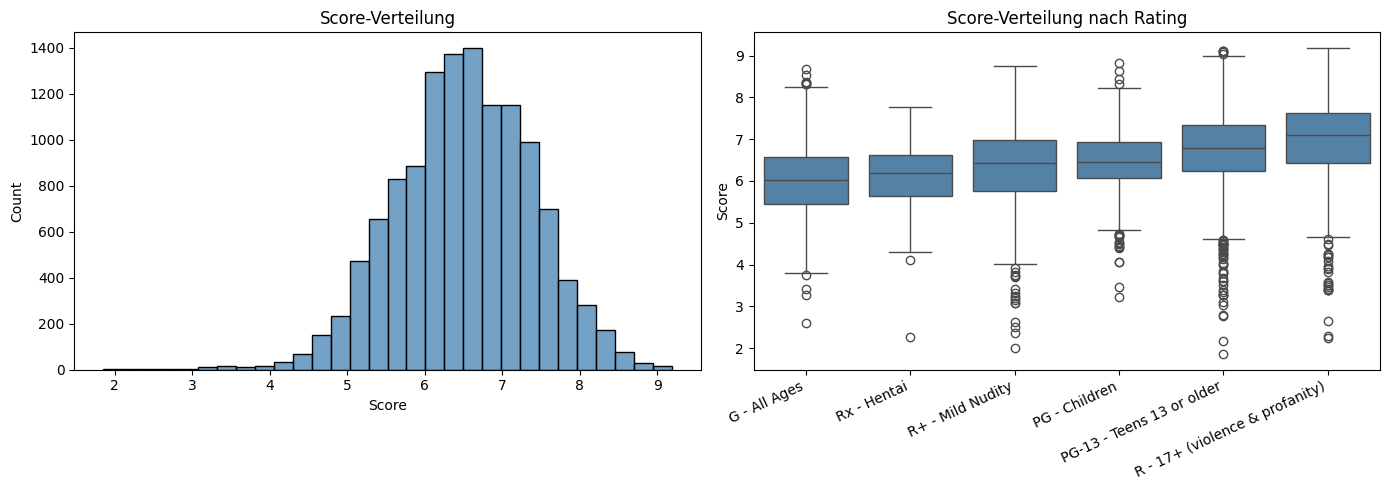

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score-Verteilung
sns.histplot(df_scored['Score'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Score-Verteilung')
axes[0].set_xlabel('Score')

# Score nach Rating (Boxplot, sortiert nach Median)
rating_order = (
    df_scored.groupby('Rating')['Score'].median()
    .sort_values()
    .index.tolist()
)
sns.boxplot(data=df_scored, x='Rating', y='Score', order=rating_order, ax=axes[1], color='steelblue')
axes[1].set_title('Score-Verteilung nach Rating')
axes[1].set_xlabel('')
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

### Score nach Type, Source und Genre

/tmp/ipykernel_32017/160723107.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(bp_data, labels=top_genres_sorted, vert=False, patch_artist=True,


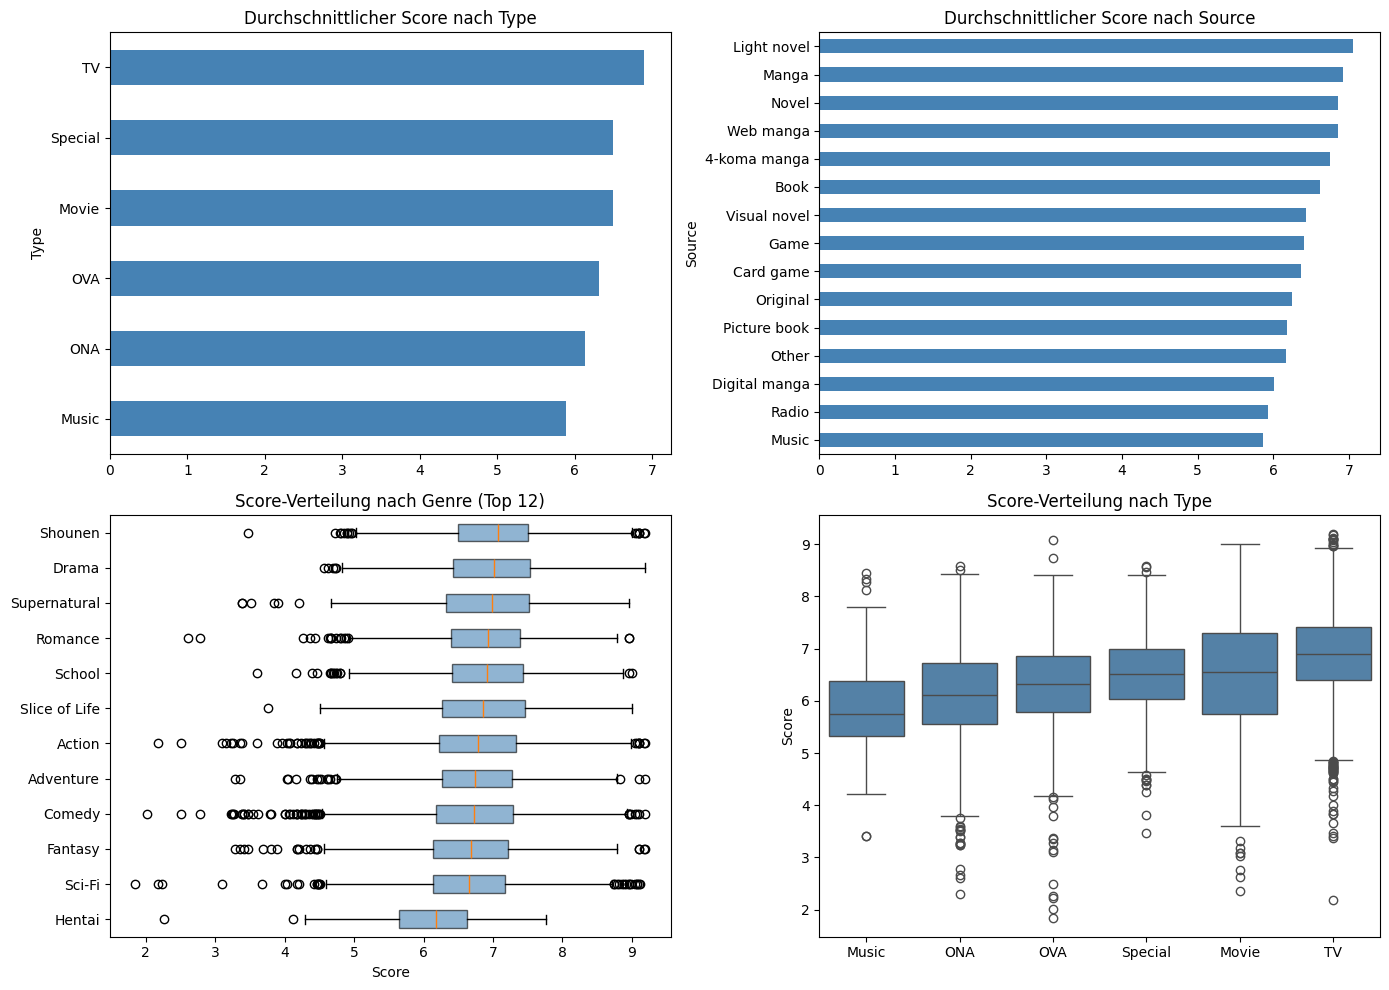

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Oben links: Durchschnittlicher Score nach Type
df_scored.groupby('Type')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Durchschnittlicher Score nach Type')

# Oben rechts: Durchschnittlicher Score nach Source
df_scored.groupby('Source')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Durchschnittlicher Score nach Source')

# Unten links: Score-Verteilung nach Genre (Top 12 Genres, sortiert nach Median-Score)
all_genres_count = df_scored['Genres'].dropna().str.split(', ').explode().value_counts()
top_genres = all_genres_count.head(12).index.tolist()
top_genres_sorted = sorted(
    top_genres,
    key=lambda g: df_scored.loc[df_scored['Genres'].str.contains(g, na=False), 'Score'].median(),
)
bp_data = [df_scored.loc[df_scored['Genres'].str.contains(g, na=False), 'Score'].dropna().values
           for g in top_genres_sorted]
axes[1, 0].boxplot(bp_data, labels=top_genres_sorted, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1, 0].set_title('Score-Verteilung nach Genre (Top 12)')
axes[1, 0].set_xlabel('Score')

# Unten rechts: Score-Verteilung nach Type (Boxplot, sortiert nach Median)
type_order = df_scored.groupby('Type')['Score'].median().sort_values().index.tolist()
sns.boxplot(data=df_scored, x='Type', y='Score', order=type_order,
            ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Score-Verteilung nach Type')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Korrelationsanalyse

In acht Schritten bauen wir den Feature-Satz für die Regression auf:

| Schritt | Feature | Quelle |
|---|---|---|
| 3.1 | 43 Genres (One-Hot) + `is_TV` | Genres-Spalte, Type-Spalte |
| 3.2 | `studio_avg_score` | Durchschnitts-Score des besten Studios eines Anime |
| 3.3 | Source & Rating (One-Hot) | je ≥ 20 Anime pro Kategorie |
| 3.4 | `is_Winter` | Saison aus Premiered + Aired-Fallback |
| 3.5 | `duration_min` | Parser aus Duration-String |
| 3.6 | Korrelations-Analyse | Barplot + Genre-Heatmap |
| 3.7 | Feature-Set zusammenstellen | `feature_cols` |
| 3.8 | Train/Test-Split | für die Pipeline |

**Bewusst ausgeschlossen:**
- *Members* — zirkulär: viele Members, *weil* beliebt
- *Episodes* — zirkulär: eine Serie läuft weiter, *weil* erfolgreich

### 3.1 Genres (One-Hot) + Type-Flag `is_TV`

**Genres:** Jeder Anime hat eine kommaseparierte Liste (`"Action, Adventure, ..."`). One-Hot-kodiert ergibt das 43 binäre Spalten — eine pro Genre mit mindestens 20 Anime.

**`is_TV`:** Aus der Spalte `Type` (TV / Movie / OVA / ONA / Special / Music) — markiert nur die TV-Serien.

> *Nicht zu verwechseln mit `Source` in 3.3 (Manga / Original / Light Novel etc.) — `Type` ist das **Sende-Format**, `Source` ist die **Vorlage**.*

In [6]:
all_genre_counts = df_scored['Genres'].dropna().str.split(', ').explode().value_counts()
valid_genres = all_genre_counts[all_genre_counts >= 20].index.tolist()

print(f"Genres gesamt:           {all_genre_counts.shape[0]}")
print(f"Genres verwendet (>=20): {len(valid_genres)}")

for genre in valid_genres:
    df_scored[genre] = df_scored['Genres'].str.contains(genre, na=False).astype(int)

df_scored['is_TV'] = (df_scored['Type'] == 'TV').astype(int)

Genres gesamt:           43
Genres verwendet (>=20): 43


### 3.2 Studio-Qualitätsscore

Studios wie Madhouse, Bones oder Kyoto Animation produzieren konsistent besser bewertete Anime. Dieser Effekt ist in den Genre-Features unsichtbar — ein eigenes Feature ist nötig.

**Methode:** Für jedes Studio wird der Durchschnittsscore aller seiner Anime im Datensatz berechnet. Hat ein Anime mehrere Studios, wird das Maximum genommen (bestes Studio zählt).

In [7]:
studio_scores_map = {}
for _, row in df_scored.iterrows():
    if pd.isna(row['Studios']):
        continue
    for studio in str(row['Studios']).split(','):
        studio = studio.strip()
        if studio:
            studio_scores_map.setdefault(studio, []).append(row['Score'])

studio_avg = {s: np.mean(v) for s, v in studio_scores_map.items()}


def get_best_studio_score(studios_str):
    if pd.isna(studios_str):
        return np.nan
    scores = [studio_avg.get(s.strip()) for s in str(studios_str).split(',') if s.strip()]
    valid = [s for s in scores if s is not None]
    return max(valid) if valid else np.nan


global_mean_score = df_scored['Score'].mean()
df_scored['studio_avg_score'] = (
    df_scored['Studios'].apply(get_best_studio_score).fillna(global_mean_score)
)

print(f"Fehlende Studio-Werte (mit globalem Mittel {global_mean_score:.2f} gefuellt): "
      f"{df_scored['Studios'].isna().sum()}")
print(f"\nTop 10 Studios nach Durchschnittsscore:")
print(pd.Series(studio_avg).sort_values(ascending=False).head(10).round(2).to_string())

Fehlende Studio-Werte (mit globalem Mittel 6.51 gefuellt): 3511

Top 10 Studios nach Durchschnittsscore:
Studio Bind                        8.37
Egg Firm                           8.32
Studio Chizu                       8.10
Nippon Ramayana Film Co.           8.04
Colored-Pencil Animation Design    8.03
Samsara Animation Studio           8.00
Djinn Power                        7.83
Purple Cow Studio Japan            7.72
Code                               7.71
Shuka                              7.71


### 3.3 Source & Rating (One-Hot)

Source und Rating sind kategorial. One-Hot mit Schwelle >= 20 Anime pro Kategorie filtert seltene Auspraegungen. Hier entsteht der vollstaendige Roh-Feature-Satz, auf dem die anschliessende Korrelations- und Heatmap-Analyse die Reduktion motiviert.

In [8]:
source_dummies = pd.get_dummies(df_scored['Source'], prefix='src').astype(int)
valid_sources = [c for c in source_dummies.columns if source_dummies[c].sum() >= 20]
for col in valid_sources:
    df_scored[col] = source_dummies[col]

rating_dummies = pd.get_dummies(df_scored['Rating'], prefix='rating').astype(int)
valid_ratings = [c for c in rating_dummies.columns if rating_dummies[c].sum() >= 20]
for col in valid_ratings:
    df_scored[col] = rating_dummies[col]

# Roh-Feature-Satz fuer die folgende Korrelationsanalyse (wird in den naechsten
# Cells um is_Winter und duration_min erweitert)
all_features = (
    valid_genres + ['is_TV']
    + valid_sources + valid_ratings + ['studio_avg_score']
)

print(f"Roh-Features bisher: {len(all_features)}")
print(f"  Genres:    {len(valid_genres)}")
print(f"  Source:    {len(valid_sources)}")
print(f"  Rating:    {len(valid_ratings)}")
print(f"  Sonstige:  2  (is_TV, studio_avg_score)")

Roh-Features bisher: 64
  Genres:    43
  Source:    13
  Rating:    6
  Sonstige:  2  (is_TV, studio_avg_score)


### 3.4 Saison (`is_Winter`)

`Premiered` ist nur fuer 31 % der Anime gefuellt, `Aired` jedoch fuer 99.9 %. Die Saison aus `Aired` per Kalender-Mapping abgeleitet stimmt zu 94 % mit `Premiered` ueberein -- die Mismatches sind alle Saison-Grenzfaelle (Ende September -> Fall etc.). Wir nehmen `Premiered` wo vorhanden, sonst die abgeleitete Saison.

Effekt im Datensatz: Winter-Anime scoren im Schnitt 0.2 Punkte niedriger als die anderen drei Saisons. Daher: `is_Winter` als einzelnes Binaer-Feature (sparsamer als 4 Dummies, wo nur einer signifikant waere).

In [9]:
start_str = df_scored['Aired'].str.split(' to ').str[0]
aired_start = pd.to_datetime(start_str, errors='coerce', format='%b %d, %Y')
mask = aired_start.isna() & start_str.notna()
aired_start.loc[mask] = pd.to_datetime(start_str[mask], errors='coerce', format='%b %Y')
mask = aired_start.isna() & start_str.notna()
aired_start.loc[mask] = pd.to_datetime(start_str[mask], errors='coerce', format='%Y')


def _month_to_season(m):
    if pd.isna(m):
        return np.nan
    m = int(m)
    if m in (1, 2, 3):
        return 'Winter'
    if m in (4, 5, 6):
        return 'Spring'
    if m in (7, 8, 9):
        return 'Summer'
    return 'Fall'


derived_season = aired_start.dt.month.map(_month_to_season)
prem_season = df_scored['Premiered'].str.split(' ', n=1, expand=True)[0]
df_scored['Season'] = prem_season.fillna(derived_season)
df_scored['is_Winter'] = (df_scored['Season'] == 'Winter').astype(int)

print(f"Saison abgedeckt: {df_scored['Season'].notna().sum()} / {len(df_scored)} "
      f"({df_scored['Season'].notna().mean() * 100:.1f}%)")
print('\nSaison-Verteilung:')
print(df_scored['Season'].value_counts().to_string())

corr_w = df_scored[['is_Winter', 'Score']].corr().iloc[0, 1]
print(f'\nKorrelation is_Winter <-> Score: {corr_w:.4f}')

# is_Winter zum Roh-Feature-Satz hinzufuegen
all_features = all_features + ['is_Winter']
print(f'\nRoh-Features inkl. is_Winter: {len(all_features)}')

Saison abgedeckt: 12294 / 12421 (99.0%)

Saison-Verteilung:
Season
Winter    3291
Fall      3281
Spring    2940
Summer    2782

Korrelation is_Winter <-> Score: -0.1108

Roh-Features inkl. is_Winter: 65


### 3.5 Episodendauer (`duration_min`)

`Duration` ist fuer 99.8 % der Anime gefuellt, aber als Freitext-String (`24 min. per ep.`, `1 hr. 45 min.`, `30 sec.`). Parser konvertiert in Minuten.

Korrelation mit Score ist mit |r| = 0.30 deutlich -- das ist auf Augenhoehe mit `is_TV`. Inhaltlich ist auch ein nichtlineares Muster sichtbar: sehr kurze Web-Shorts (<=5 min) scoren niedrig (~5.9), Standard-TV (16-25 min) und Filme (1-3 h) scoren hoch (~6.9 - 7.0). Lineare Modelle erfassen das nur teilweise, Tree-Modelle koennen den nichtlinearen Verlauf lernen.

In [10]:
import re


def parse_duration(s):
    """Konvertiere Duration-String in Minuten (float)."""
    if pd.isna(s):
        return np.nan
    s = s.strip()
    m = re.match(r'(\d+)\s*hr\.\s*(\d+)\s*min', s)
    if m:
        return int(m.group(1)) * 60 + int(m.group(2))
    m = re.match(r'(\d+)\s*hr', s)
    if m:
        return int(m.group(1)) * 60
    m = re.match(r'(\d+)\s*min', s)
    if m:
        return int(m.group(1))
    m = re.match(r'(\d+)\s*sec', s)
    if m:
        return int(m.group(1)) / 60
    return np.nan


df_scored['duration_min'] = df_scored['Duration'].apply(parse_duration)

# Wenige fehlende Werte (~23) mit Median fuellen -- vermeidet NaN-Probleme im Modell
median_dur = df_scored['duration_min'].median()
df_scored['duration_min'] = df_scored['duration_min'].fillna(median_dur)

print(f"Duration geparst: {df_scored['Duration'].notna().sum()} / {len(df_scored)} "
      f"({df_scored['Duration'].notna().mean()*100:.1f}%)")
print(f"Median: {median_dur:.1f} min  (fuer fehlende Werte verwendet)")
print(f"\nKorrelation duration_min <-> Score: "
      f"{df_scored[['duration_min', 'Score']].corr().iloc[0, 1]:.4f}")

# Score-Verteilung nach Dauer-Bucket -- zeigt das nichtlineare Muster
buckets = pd.cut(
    df_scored['duration_min'],
    bins=[0, 5, 15, 25, 35, 60, 180, 9999],
    labels=['<=5min', '6-15min', '16-25min', '26-35min', '36-60min', '1-3h', '>3h'],
)
print('\nScore-Mittelwert pro Dauer-Bucket:')
print(df_scored.groupby(buckets, observed=True)['Score'].agg(['count', 'mean']).round(3).to_string())

all_features = all_features + ['duration_min']
print(f"\nRoh-Features gesamt: {len(all_features)}")

Duration geparst: 12398 / 12421 (99.8%)
Median: 24.0 min  (fuer fehlende Werte verwendet)

Korrelation duration_min <-> Score: 0.2954

Score-Mittelwert pro Dauer-Bucket:
              count   mean
duration_min              
<=5min         2647  5.883
6-15min        1320  6.235
16-25min       4747  6.900
26-35min       1732  6.337
36-60min        801  6.374
1-3h           1174  7.003

Roh-Features gesamt: 66


### 3.6 Korrelations-Analyse

Zwei Diagramme auf dem vollstaendigen Roh-Feature-Satz:
1. **Korrelations-Barplot** -- Welche Features haben einen messbaren linearen Bezug zu `Score`?
2. **Genre-Genre-Heatmap** -- Welche Genres treten gemeinsam auf (deskriptive Uebersicht)

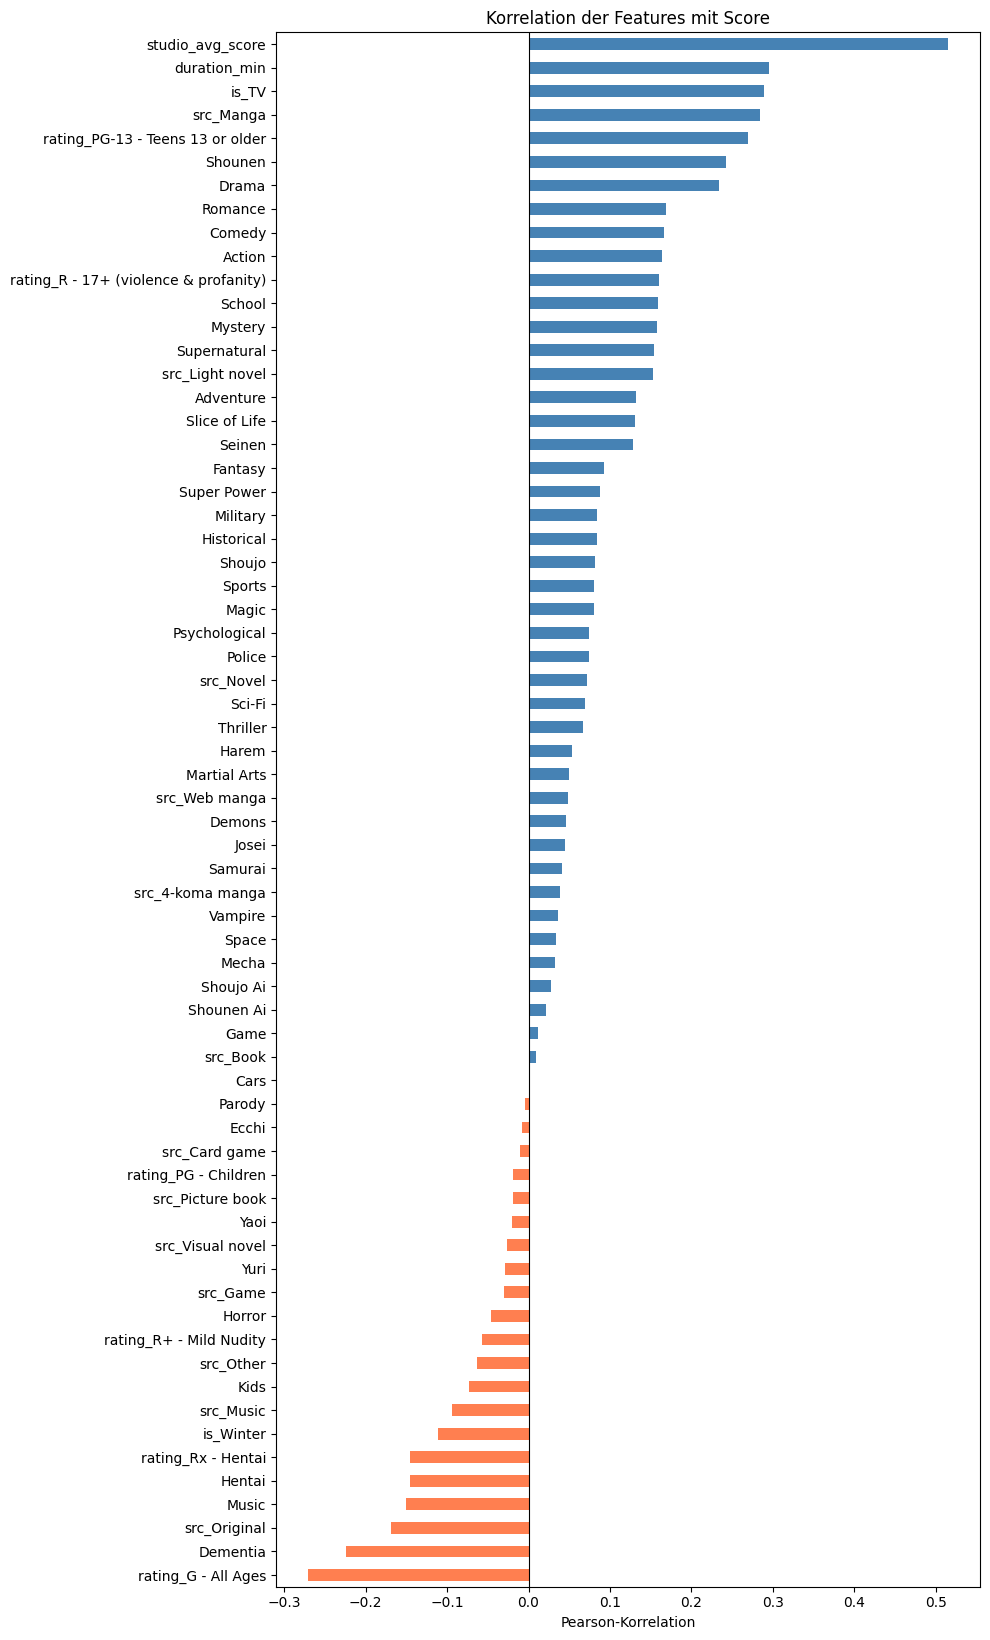

Top 5 positiv korreliert:
rating_PG-13 - Teens 13 or older    0.269
src_Manga                           0.284
is_TV                               0.290
duration_min                        0.295
studio_avg_score                    0.515
Name: Score, dtype: float64

Top 5 negativ korreliert:
rating_G - All Ages   -0.271
Dementia              -0.224
src_Original          -0.169
Music                 -0.151
Hentai                -0.146
Name: Score, dtype: float64


In [11]:
corr_with_target = (
    df_scored[all_features + ['Score']]
    .corr()['Score']
    .drop('Score')
    .sort_values()
)

colors = ['coral' if c < 0 else 'steelblue' for c in corr_with_target]

plt.figure(figsize=(10, max(8, len(corr_with_target) * 0.25)))
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korrelation der Features mit Score')
plt.xlabel('Pearson-Korrelation')
plt.tight_layout()
plt.show()

print("Top 5 positiv korreliert:")
print(corr_with_target.tail(5).round(3))
print("\nTop 5 negativ korreliert:")
print(corr_with_target.head(5).round(3))

#### Genre-Genre-Heatmap (Top 20 nach Häufigkeit)

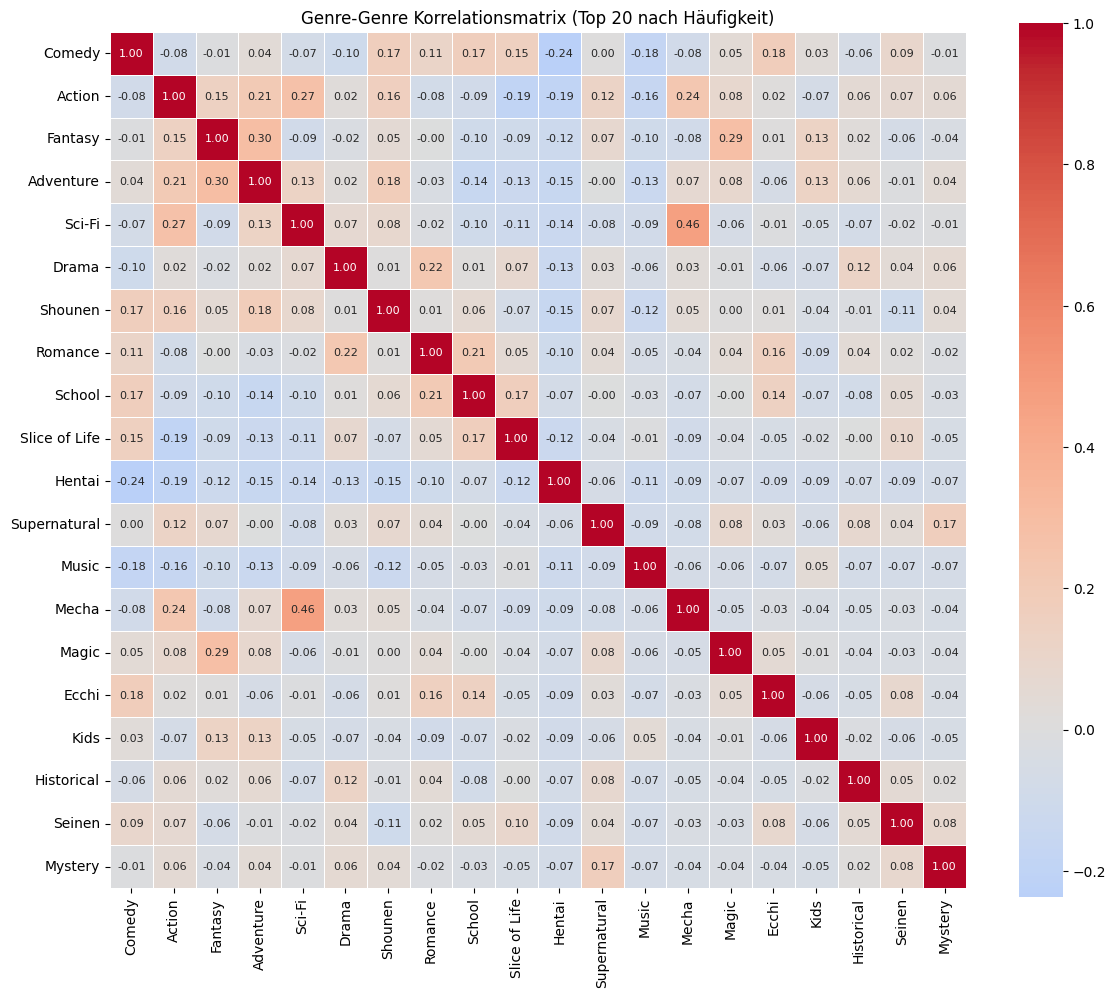

In [12]:
top_20_genres = all_genre_counts.head(20).index.tolist()
corr_matrix = df_scored[top_20_genres].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    square=True,
    annot_kws={'size': 8},
)
plt.title('Genre-Genre Korrelationsmatrix (Top 20 nach Häufigkeit)')
plt.tight_layout()
plt.show()

### 3.7 Feature-Set zusammenstellen

| Gruppe | Features | Anmerkung |
|---|---|---|
| Genres | 43 (One-Hot) | Einzelgenres -- bei 12.4k Samples kein Overfit-Risiko |
| Source | alle Kategorien (>= 20 Anime) | One-Hot |
| Rating | alle Kategorien | One-Hot (G, PG, PG-13, R, R+, Rx) |
| Studio | `studio_avg_score` | Durchschnittsscore des besten Studios eines Anime |
| Zeit | `is_Winter` | Saison aus Premiered + Aired-Fallback |

**Bewusst ausgeschlossen:**
- *Members* -- zirkulaer: ein Anime hat viele Members, *weil* er beliebt ist
- *Episodes* -- zirkulaer: eine Serie laeuft weiter, *weil* sie erfolgreich ist

In [13]:
feature_cols = (
    valid_genres + ['is_TV'] + valid_sources + valid_ratings
    + ['studio_avg_score', 'is_Winter', 'duration_min']
)

print(f"Feature-Anzahl gesamt: {len(feature_cols)}")
print(f"  Genres:    {len(valid_genres)}")
print(f"  Source:    {len(valid_sources)}")
print(f"  Rating:    {len(valid_ratings)}")
print(f"  Sonstige:  4  (is_TV, studio_avg_score, is_Winter, duration_min)")

Feature-Anzahl gesamt: 66
  Genres:    43
  Source:    13
  Rating:    6
  Sonstige:  4  (is_TV, studio_avg_score, is_Winter, duration_min)


### 3.8 Feature-Selektion und Train/Test-Split

Die Auswahl der besten K Features passiert **in der Pipeline** statt vorher — über `SelectKBest`. Der Selektor bewertet jedes Feature einzeln, wie stark es mit `Score` zusammenhängt, und behält die K stärksten.

*Detail:* Konkret nutzt `SelectKBest` die **F-Statistik** als Score — eine Kennzahl, die mathematisch eng verwandt mit dem Pearson-Korrelationskoeffizienten ist. Praktisch heißt das: die Reihenfolge ist quasi dieselbe, wie wenn wir nach |r| sortieren würden.

Zwei Vorteile dieser Pipeline-Auswahl:
1. **Kein Datenleck** — die Auswahl sieht nur die Trainingsdaten (würden wir vorher selektieren, fließt Test-Information mit ein)
2. **K wird tunbar** — in Sektion 4 sweepen wir K von 5 bis 40 und sehen, wo Underfit aufhört und Overfit anfängt

Der Train/Test-Split fixiert `random_state=42` für Reproduzierbarkeit.

In [14]:
from sklearn.model_selection import train_test_split

df_model = df_scored[feature_cols + ['Score']].dropna()
X = df_model[feature_cols]
y = df_model['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Trainingsdaten: {X_train.shape[0]} Zeilen, {X_train.shape[1]} Features")
print(f"Testdaten:      {X_test.shape[0]} Zeilen")
print(f"Mittlerer Anime-Score im Training: {y_train.mean():.2f} ± {y_train.std():.2f}")
print(f"Mittlerer Anime-Score im Test:     {y_test.mean():.2f} ± {y_test.std():.2f}")

X_train.head()

Trainingsdaten: 9936 Zeilen, 66 Features
Testdaten:      2485 Zeilen
Mittlerer Anime-Score im Training: 6.52 ± 0.89
Mittlerer Anime-Score im Test:     6.49 ± 0.89


,Comedy,Action,Fantasy,Adventure,Sci-Fi,Drama,Shounen,Romance,School,Slice of Life,Hentai,Supernatural,Music,Mecha,Magic,Ecchi,Kids,Historical,Seinen,Mystery,Shoujo,Sports,Super Power,Military,Parody,Demons,Space,Horror,Harem,Martial Arts,Psychological,Dementia,Game,Police,Samurai,Vampire,Thriller,Josei,Shounen Ai,Shoujo Ai,Cars,Yaoi,Yuri,is_TV,src_4-koma manga,src_Book,src_Card game,src_Game,src_Light novel,src_Manga,src_Music,src_Novel,src_Original,src_Other,src_Picture book,src_Visual novel,src_Web manga,rating_G - All Ages,rating_PG - Children,rating_PG-13 - Teens 13 or older,rating_R - 17+ (violence & profanity),rating_R+ - Mild Nudity,rating_Rx - Hentai,studio_avg_score,is_Winter,duration_min
2252,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,6.893245,0,13.0
2775,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,6.038667,0,30.0
14007,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,6.928500,0,3.0
5725,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,6.509999,0,37.0
11097,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,6.509999,0,1.0


## 4. Regression

Zielvariable: `Score` (kontinuierlich, 1.85-9.19).

**Pipeline:** `SelectKBest(f_regression) -> StandardScaler -> Modell`.

**Zwei Schritte:**
1. **K-Sweep** (K = 5 .. 40) -- visualisiert, wie sich Performance mit der Feature-Anzahl entwickelt
2. **GridSearchCV** -- tuned Hyperparameter pro Modell per 5-fold Cross-Validation

Metriken: **RMSE** (Score-Punkte), **MAE** (robuster gegen Ausreisser), **R^2** (erklaerte Varianz).

### 4.1 K-Sweep — wie viel K ist optimal?

Wir testen K von 5 bis 40 über alle drei Modelle und plotten RMSE und R² als Funktion von K. Daraus liest man optisch ab, wo jedes Modell sein Optimum erreicht.

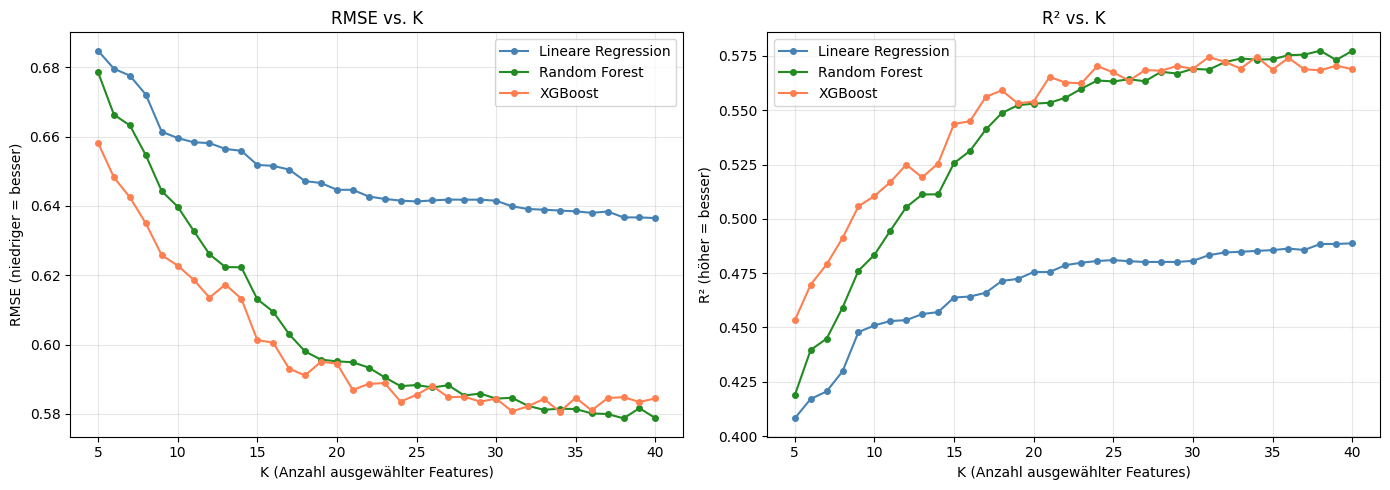

Bestes K pro Modell (nach niedrigstem RMSE):
 K             Modell   RMSE    MAE     R2
38      Random Forest 0.5787 0.4419 0.5774
34            XGBoost 0.5806 0.4461 0.5746
40 Lineare Regression 0.6365 0.4995 0.4887

Gewähltes K pro Modell:
  LR  -> K = 40
  RF  -> K = 38
  XGB -> K = 34


In [15]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

K_RANGE = list(range(5, 41))

base_models = {
    'Lineare Regression': lambda: LinearRegression(),
    'Random Forest': lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse'),
}

records = []
for k in K_RANGE:
    for name, ctor in base_models.items():
        pipe = Pipeline([
            ('select', SelectKBest(f_regression, k=k)),
            ('scaler', StandardScaler()),
            ('model', ctor()),
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        records.append({
            'K': k,
            'Modell': name,
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred),
        })

sweep_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Lineare Regression': 'steelblue', 'Random Forest': 'forestgreen', 'XGBoost': 'coral'}
for name, color in colors.items():
    sub = sweep_df[sweep_df['Modell'] == name]
    axes[0].plot(sub['K'], sub['RMSE'], marker='o', label=name, color=color, markersize=4)
    axes[1].plot(sub['K'], sub['R2'], marker='o', label=name, color=color, markersize=4)

axes[0].set_xlabel('K (Anzahl ausgewählter Features)')
axes[0].set_ylabel('RMSE (niedriger = besser)')
axes[0].set_title('RMSE vs. K')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel('K (Anzahl ausgewählter Features)')
axes[1].set_ylabel('R² (höher = besser)')
axes[1].set_title('R² vs. K')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Bestes K pro Modell ermitteln
best_per_model = (
    sweep_df.loc[sweep_df.groupby('Modell')['RMSE'].idxmin()]
    .sort_values('RMSE')
    .round(4)
)
print('Bestes K pro Modell (nach niedrigstem RMSE):')
print(best_per_model.to_string(index=False))

BEST_K_LR = int(best_per_model[best_per_model['Modell'] == 'Lineare Regression']['K'].iloc[0])
BEST_K_RF = int(best_per_model[best_per_model['Modell'] == 'Random Forest']['K'].iloc[0])
BEST_K_XGB = int(best_per_model[best_per_model['Modell'] == 'XGBoost']['K'].iloc[0])
print(f'\nGewähltes K pro Modell:')
print(f'  LR  -> K = {BEST_K_LR}')
print(f'  RF  -> K = {BEST_K_RF}')
print(f'  XGB -> K = {BEST_K_XGB}')

### 4.2 Hyperparameter-Tuning mit GridSearchCV

`GridSearchCV(estimator, param_grid, cv=5)` testet jede Kombination per 5-fold Cross-Validation und gibt die beste zurück. Jedes Modell nutzt sein eigenes bestes K aus dem Sweep — getunt werden nur die Modell-Parameter.

**Pragmatische Entscheidung aus den Vorläufen:**
- **LR:** Default-Konfiguration gewinnt — LinearRegression hat schlicht keine sinnvoll tunbaren Parameter, also bleibt's bei der einfachen Pipeline.
- **RF:** GridSearchCV brachte nur minimale Verbesserung — innerhalb des K-Sweep-Rauschens, nicht den Aufwand wert.
- **XGB:** Spürbarer Gain (~1.5 %) — wird als Demonstration der Technik beibehalten.

#### Lineare Regression (Default)

In [16]:
lr_pipe = Pipeline([
    ('select', SelectKBest(f_regression, k=BEST_K_LR)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print(f"=== LINEARE REGRESSION  (Default, K={BEST_K_LR}) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.3f}")

=== LINEARE REGRESSION  (Default, K=40) ===
RMSE: 0.636
MAE:  0.499
R²:   0.489


#### Random Forest (Default)

=== RANDOM FOREST REGRESSOR  (Default, K=38) ===
RMSE: 0.579
MAE:  0.442
R²:   0.577


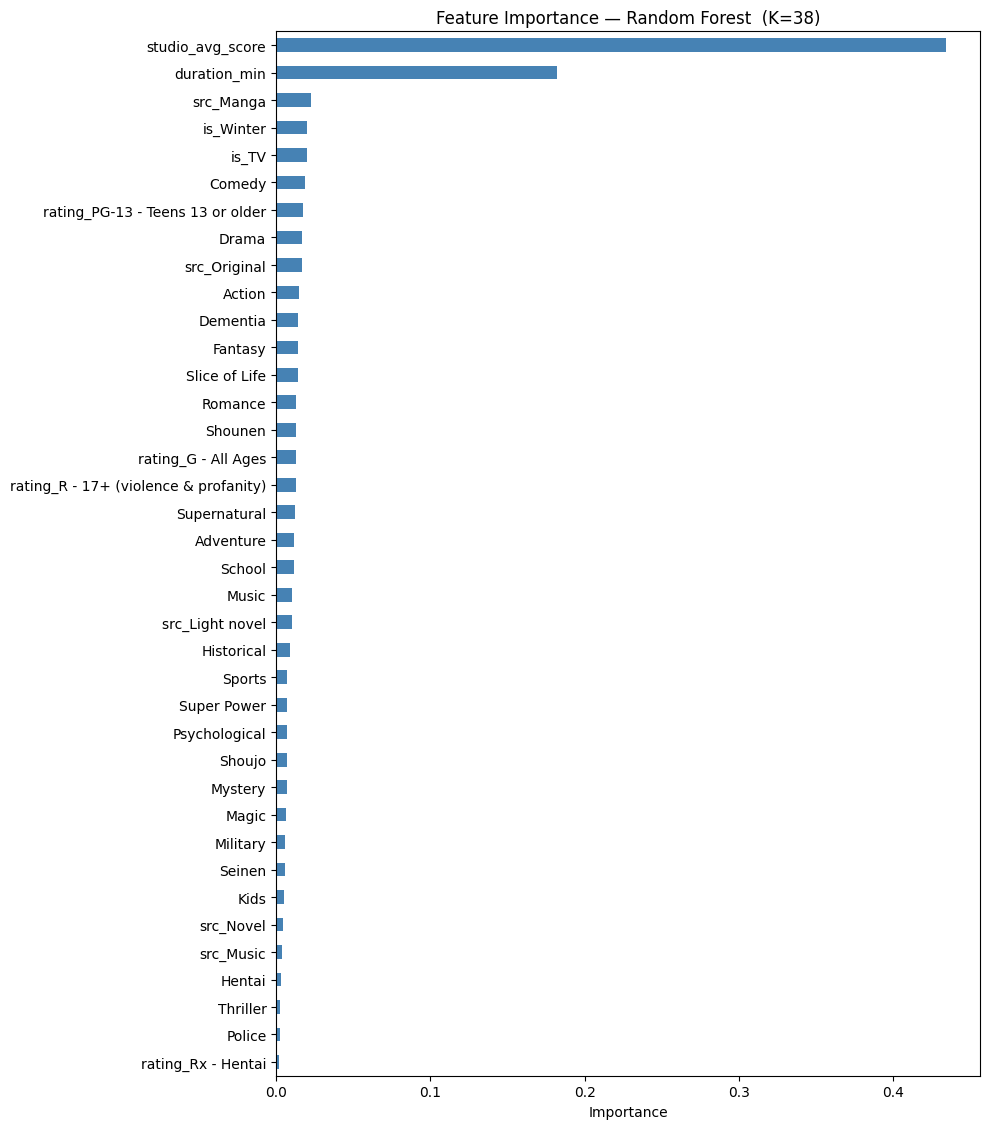

In [17]:
rf_pipe = Pipeline([
    ('select', SelectKBest(f_regression, k=BEST_K_RF)),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print(f"=== RANDOM FOREST REGRESSOR  (Default, K={BEST_K_RF}) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.3f}")

selected_rf = X_train.columns[rf_pipe.named_steps['select'].get_support()].tolist()
importance_rf = pd.Series(
    rf_pipe.named_steps['model'].feature_importances_,
    index=selected_rf,
).sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(importance_rf) * 0.30)))
importance_rf.plot(kind='barh', color='steelblue')
plt.title(f'Feature Importance — Random Forest  (K={BEST_K_RF})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

#### XGBoost (mit GridSearchCV)

=== XGBOOST REGRESSOR  (GridSearchCV, K=34) ===
Default CV RMSE: 0.5925
Tuned   CV RMSE: 0.5835
Gain:            +1.526%
Best params:     {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 300}

Test RMSE: 0.572
Test MAE:  0.438
Test R²:   0.587


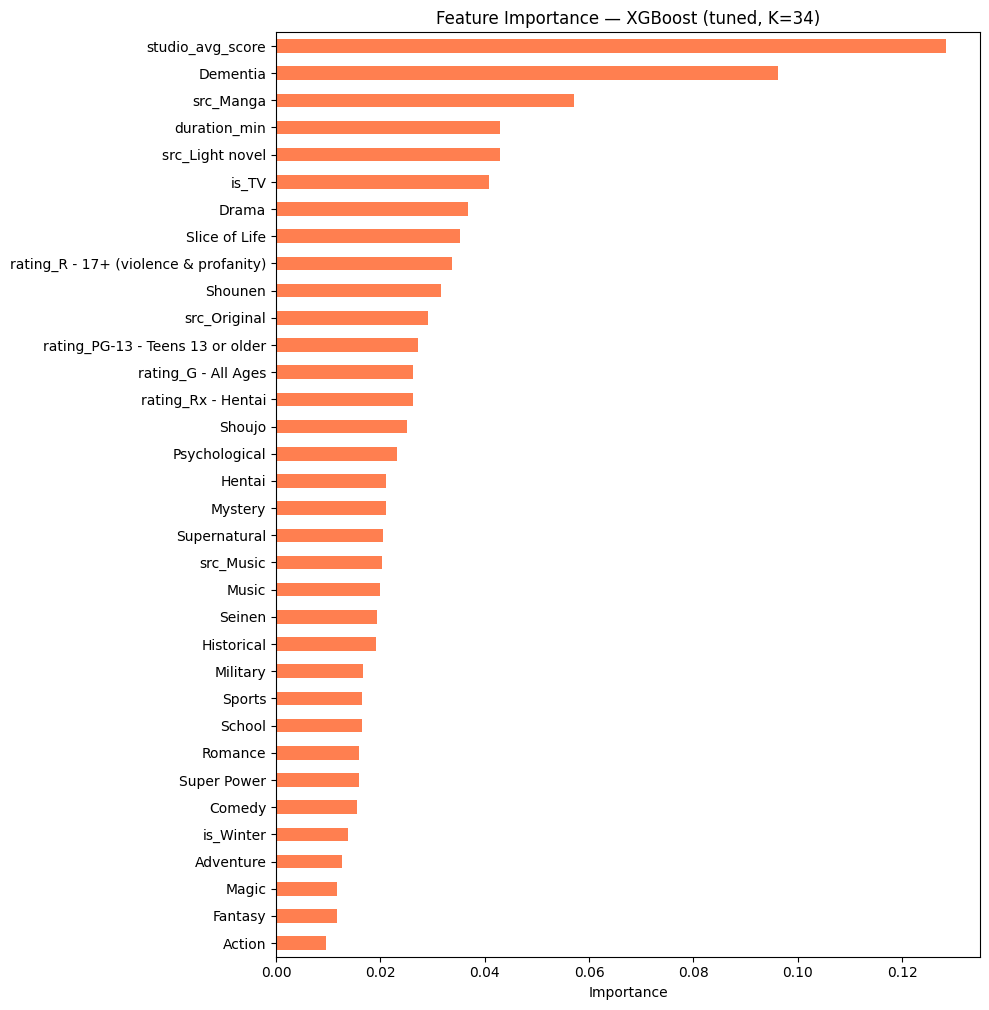

In [18]:
from sklearn.model_selection import GridSearchCV, cross_val_score

xgb_pipe = Pipeline([
    ('select', SelectKBest(f_regression, k=BEST_K_XGB)),
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42, eval_metric='rmse')),
])

default_cv_xgb = -cross_val_score(
    xgb_pipe, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1
).mean()

param_grid_xgb = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
}

gs_xgb = GridSearchCV(xgb_pipe, param_grid_xgb, cv=5,
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_xgb.fit(X_train, y_train)

tuned_cv_xgb = -gs_xgb.best_score_
gain_xgb = (default_cv_xgb - tuned_cv_xgb) / default_cv_xgb * 100

print(f"=== XGBOOST REGRESSOR  (GridSearchCV, K={BEST_K_XGB}) ===")
print(f"Default CV RMSE: {default_cv_xgb:.4f}")
print(f"Tuned   CV RMSE: {tuned_cv_xgb:.4f}")
print(f"Gain:            {gain_xgb:+.3f}%")
print(f"Best params:     {gs_xgb.best_params_}\n")

y_pred_xgb = gs_xgb.best_estimator_.predict(X_test)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"Test R²:   {r2_score(y_test, y_pred_xgb):.3f}")

selected_xgb = X_train.columns[gs_xgb.best_estimator_.named_steps['select'].get_support()].tolist()
importance_xgb = pd.Series(
    gs_xgb.best_estimator_.named_steps['model'].feature_importances_,
    index=selected_xgb,
)
importance_xgb = importance_xgb[importance_xgb > 0].sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(importance_xgb) * 0.30)))
importance_xgb.plot(kind='barh', color='coral')
plt.title(f'Feature Importance — XGBoost (tuned, K={BEST_K_XGB})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 4.3 Vergleich + Predicted-vs-Actual

            Modell  K  RMSE   MAE    R²
Lineare Regression 40 0.636 0.499 0.489
     Random Forest 38 0.579 0.442 0.577
           XGBoost 34 0.572 0.438 0.587


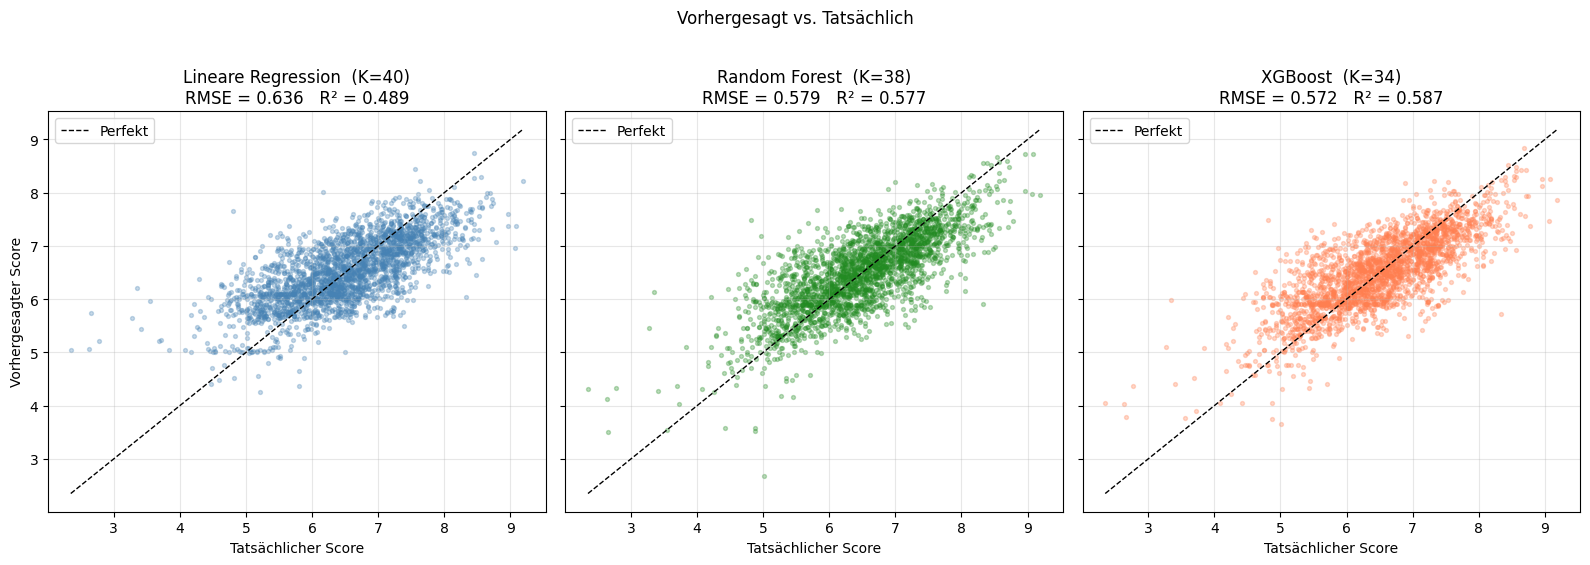

In [19]:
results = pd.DataFrame({
    'Modell': ['Lineare Regression', 'Random Forest', 'XGBoost'],
    'K': [BEST_K_LR, BEST_K_RF, BEST_K_XGB],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
    ],
}).round(3)
print(results.to_string(index=False))

# Vorhergesagt vs. Tatsächlich — alle drei Modelle nebeneinander
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)

panels = [
    (y_pred_lr,  'Lineare Regression', f'K={BEST_K_LR}',  'steelblue'),
    (y_pred_rf,  'Random Forest',      f'K={BEST_K_RF}',  'forestgreen'),
    (y_pred_xgb, 'XGBoost',            f'K={BEST_K_XGB}', 'coral'),
]
y_min, y_max = y_test.min(), y_test.max()

for ax, (y_pred, name, k_label, color) in zip(axes, panels):
    ax.scatter(y_test, y_pred, alpha=0.3, s=8, color=color)
    ax.plot([y_min, y_max], [y_min, y_max], 'k--', linewidth=1, label='Perfekt')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}  ({k_label})\nRMSE = {rmse:.3f}   R² = {r2:.3f}')
    ax.set_xlabel('Tatsächlicher Score')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left')

axes[0].set_ylabel('Vorhergesagter Score')

plt.suptitle('Vorhergesagt vs. Tatsächlich', y=1.02)
plt.tight_layout()
plt.show()

## 5. Was macht einen Top-Anime aus? (Score >= 8)

Die Regression in Sektion 4 erklaert den Score "im Durchschnitt" gut. Die eigentliche Frage des Projekts war aber spezifischer: *was unterscheidet einen Top-Anime von den anderen?*

Top-Animes (Score >= 8) machen nur ~4 % der Daten aus. Hier folgen drei aufeinander aufbauende Analysen:

1. **Slice-Performance** der Regression -- wie gut funktioniert sie auf Top vs. Rest?
2. **Deskriptiver Vergleich** -- welche Feature-Werte unterscheiden Top von Rest?
3. **Binaerer Klassifikator** Top vs. nicht-Top -- direkt auf die richtige Frage trainiert

### 5.1 Slice-Performance der Regression

Die Gesamt-Metriken aus Sektion 4 mitteln ueber alle Score-Bereiche. Splittet man Test-Set in Top (>=8) und Rest, sieht das Bild anders aus.

In [20]:
TOP_THRESHOLD = 8.0
mask_top = y_test >= TOP_THRESHOLD

def metrics_block(yt, yp):
    return (
        np.sqrt(mean_squared_error(yt, yp)),
        mean_absolute_error(yt, yp),
        r2_score(yt, yp),
        (yp - yt).mean(),
    )

records = []
for name, yp in [('LR', y_pred_lr), ('RF', y_pred_rf), ('XGB', y_pred_xgb)]:
    rmse, mae, r2, bias = metrics_block(y_test, yp)
    records.append({'Segment': 'Gesamt', 'Modell': name, 'n': len(y_test),
                    'RMSE': rmse, 'MAE': mae, 'R²': r2, 'Bias': bias})
    rmse, mae, r2, bias = metrics_block(y_test[mask_top], yp[mask_top])
    records.append({'Segment': f'Top (>= {TOP_THRESHOLD})', 'Modell': name, 'n': int(mask_top.sum()),
                    'RMSE': rmse, 'MAE': mae, 'R²': r2, 'Bias': bias})

df_slice = pd.DataFrame(records).round(3)
print(df_slice.to_string(index=False))

     Segment Modell    n  RMSE   MAE      R²   Bias
      Gesamt     LR 2485 0.636 0.499   0.489  0.028
Top (>= 8.0)     LR  102 1.020 0.917 -13.915 -0.911
      Gesamt     RF 2485 0.579 0.442   0.577  0.011
Top (>= 8.0)     RF  102 0.855 0.719  -9.486 -0.697
      Gesamt    XGB 2485 0.572 0.438   0.587  0.021
Top (>= 8.0)    XGB  102 0.849 0.714  -9.336 -0.708


#### "Regression to the mean" — Bias pro Score-Bucket

Das Modell zieht Vorhersagen Richtung Mittelwert (~6.5). Niedrige Scores werden überschätzt, hohe unterschätzt — das klassische Phänomen bei symmetrischer Verlustfunktion, wenn der Trainings-Mittelwert weit weg von den Rändern liegt.

           n  actual_mean  pred_mean  bias_mean
bucket                                         
<5       106        4.558      5.354      0.795
5-6      617        5.570      5.969      0.399
6-7     1012        6.489      6.505      0.015
7-8      651        7.385      7.041     -0.345
8-9       96        8.293      7.600     -0.694
>=9        3        9.113      7.863     -1.250


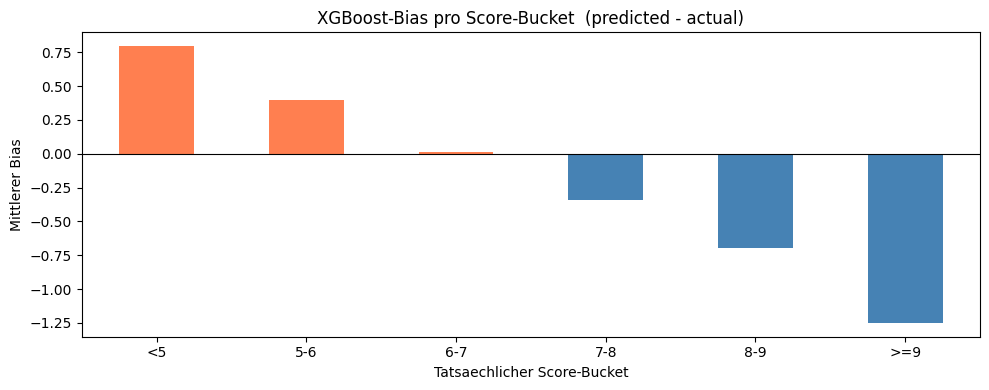

In [21]:
buckets = pd.cut(y_test, bins=[0, 5, 6, 7, 8, 9, 10],
                 labels=['<5', '5-6', '6-7', '7-8', '8-9', '>=9'])

df_bias = pd.DataFrame({
    'bucket': buckets,
    'actual': y_test.values,
    'pred': y_pred_xgb,
})
df_bias['bias'] = df_bias['pred'] - df_bias['actual']

bias_summary = df_bias.groupby('bucket', observed=True).agg(
    n=('actual', 'size'),
    actual_mean=('actual', 'mean'),
    pred_mean=('pred', 'mean'),
    bias_mean=('bias', 'mean'),
).round(3)
print(bias_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if b < 0 else 'coral' for b in bias_summary['bias_mean']]
bias_summary['bias_mean'].plot(kind='bar', color=colors, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('XGBoost-Bias pro Score-Bucket  (predicted - actual)')
ax.set_xlabel('Tatsaechlicher Score-Bucket')
ax.set_ylabel('Mittlerer Bias')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Was haben Top-Animes gemeinsam?

Direkter Vergleich der Feature-Verteilungen zwischen Top (Score >= 8) und Rest. Keine Modellierung -- nur Deskription.

In [22]:
top = df_scored[df_scored['Score'] >= TOP_THRESHOLD]
rest = df_scored[df_scored['Score'] < TOP_THRESHOLD]

print(f"Top  (Score >= {TOP_THRESHOLD}): {len(top):5d}  ({len(top)/len(df_scored)*100:.1f}%)")
print(f"Rest (Score <  {TOP_THRESHOLD}): {len(rest):5d}  ({len(rest)/len(df_scored)*100:.1f}%)\n")

print('--- Kontinuierliche Features ---')
for col in ['studio_avg_score', 'duration_min']:
    t, r = top[col].mean(), rest[col].mean()
    print(f"  {col:25s}  Top Ø {t:6.2f}   Rest Ø {r:6.2f}   Differenz {t-r:+.2f}")

binary_cols = valid_genres + ['is_TV'] + valid_sources + valid_ratings + ['is_Winter']
diffs = []
for c in binary_cols:
    p_top = top[c].mean()
    p_rest = rest[c].mean()
    diffs.append({
        'Feature': c,
        'Top %': p_top * 100,
        'Rest %': p_rest * 100,
        'Diff (pp)': (p_top - p_rest) * 100,
    })

df_diff = pd.DataFrame(diffs)
df_diff = df_diff.reindex(df_diff['Diff (pp)'].abs().sort_values(ascending=False).index)

print('\n--- Binaere Features: Top 15 Unterschiede (sortiert nach |Differenz|) ---')
print(df_diff.head(15).round(2).to_string(index=False))

Top  (Score >= 8.0):   548  (4.4%)
Rest (Score <  8.0): 11873  (95.6%)

--- Kontinuierliche Features ---
  studio_avg_score           Top Ø   7.06   Rest Ø   6.69   Differenz +0.37
  duration_min               Top Ø  42.69   Rest Ø  25.82   Differenz +16.87

--- Binaere Features: Top 15 Unterschiede (sortiert nach |Differenz|) ---
                              Feature  Top %  Rest %  Diff (pp)
                                is_TV  59.31   29.58      29.73
                            src_Manga  55.84   26.17      29.67
                                Drama  41.61   15.35      26.25
     rating_PG-13 - Teens 13 or older  65.69   42.92      22.77
                              Shounen  33.94   14.33      19.61
                  rating_G - All Ages   4.74   22.21     -17.47
rating_R - 17+ (violence & profanity)  23.91    7.99      15.91
                         Supernatural  23.91    9.85      14.06
                              Mystery  17.15    4.62      12.53
                           

#### Visualisierung: Differenz Top vs. Rest (Top-15-Features)

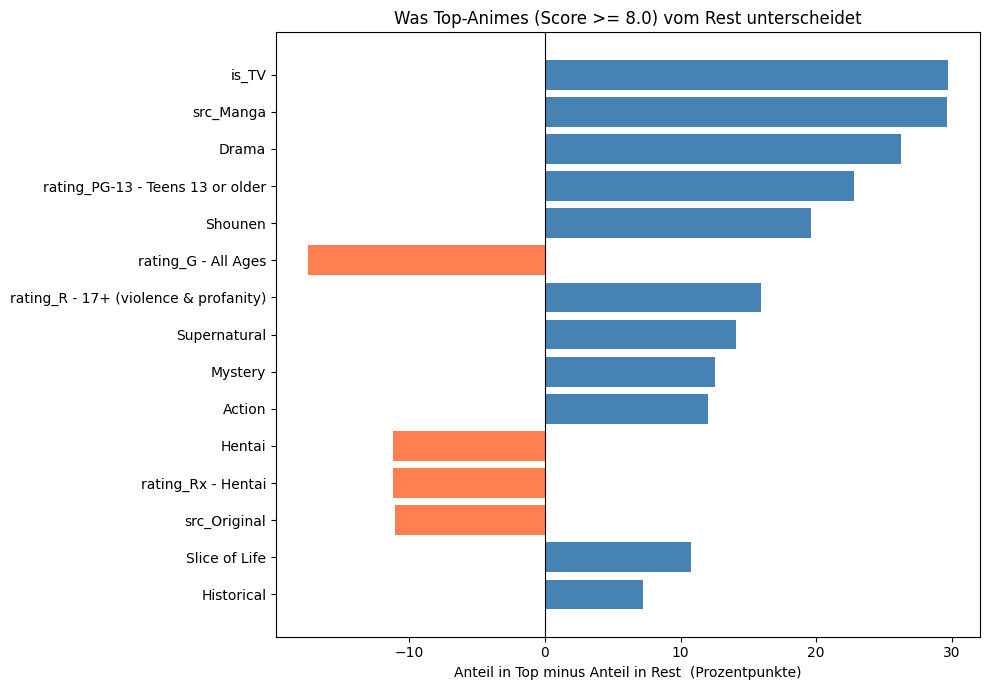

In [23]:
top_diffs = df_diff.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if d > 0 else 'coral' for d in top_diffs['Diff (pp)']]
ax.barh(top_diffs['Feature'], top_diffs['Diff (pp)'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Anteil in Top minus Anteil in Rest  (Prozentpunkte)')
ax.set_title(f'Was Top-Animes (Score >= {TOP_THRESHOLD}) vom Rest unterscheidet')
plt.tight_layout()
plt.show()

### 5.3 Binaerer Klassifikator: Top vs. nicht-Top

Direkt auf die Frage trainiert. Target: `Top = Score >= 8` (binaer). Class Imbalance ~4 % positiv, wird in den Modellen ausgeglichen:
- **Logistic Regression** mit `class_weight='balanced'` (Klassen-Gewichte invers zur Haeufigkeit)
- **XGBoost Classifier** mit `scale_pos_weight = n_neg / n_pos`

Metriken aendern sich: statt RMSE/R^2 jetzt **Precision** (von den als Top vorhergesagten, wie viele sind wirklich Top?), **Recall** (von den echten Tops, wie viele finden wir?) und **F1** (harmonisches Mittel) -- alle auf die positive Klasse. Plus **ROC-AUC** als Schwellwert-freies Mass.

In [24]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.feature_selection import f_classif
from sklearn.metrics import classification_report, roc_auc_score

df_clf = df_scored[feature_cols + ['Score']].dropna()
X_clf = df_clf[feature_cols]
y_clf = (df_clf['Score'] >= TOP_THRESHOLD).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

spw = (y_train_c == 0).sum() / (y_train_c == 1).sum()
print(f"Train: {y_train_c.sum()} Top von {len(y_train_c)} ({y_train_c.mean()*100:.1f}%)")
print(f"scale_pos_weight: {spw:.2f}\n")

logreg_pipe = Pipeline([
    ('select', SelectKBest(f_classif, k=BEST_K_XGB)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
logreg_pipe.fit(X_train_c, y_train_c)
y_pred_lr_c = logreg_pipe.predict(X_test_c)
y_prob_lr_c = logreg_pipe.predict_proba(X_test_c)[:, 1]

print("=== LOGISTIC REGRESSION  (class_weight='balanced') ===")
print(classification_report(y_test_c, y_pred_lr_c, target_names=['nicht-Top', 'Top'], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test_c, y_prob_lr_c):.3f}\n")

xgb_clf_pipe = Pipeline([
    ('select', SelectKBest(f_classif, k=BEST_K_XGB)),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             scale_pos_weight=spw, random_state=42, eval_metric='auc')),
])
xgb_clf_pipe.fit(X_train_c, y_train_c)
y_pred_xgb_c = xgb_clf_pipe.predict(X_test_c)
y_prob_xgb_c = xgb_clf_pipe.predict_proba(X_test_c)[:, 1]

print("=== XGBOOST CLASSIFIER  (scale_pos_weight) ===")
print(classification_report(y_test_c, y_pred_xgb_c, target_names=['nicht-Top', 'Top'], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test_c, y_prob_xgb_c):.3f}")

Train: 438 Top von 9936 (4.4%)
scale_pos_weight: 21.68

=== LOGISTIC REGRESSION  (class_weight='balanced') ===
              precision    recall  f1-score   support

   nicht-Top      0.991     0.800     0.886      2375
         Top      0.164     0.845     0.275       110

    accuracy                          0.802      2485
   macro avg      0.578     0.823     0.580      2485
weighted avg      0.955     0.802     0.859      2485

ROC-AUC: 0.905



=== XGBOOST CLASSIFIER  (scale_pos_weight) ===
              precision    recall  f1-score   support

   nicht-Top      0.978     0.927     0.952      2375
         Top      0.258     0.545     0.350       110

    accuracy                          0.910      2485
   macro avg      0.618     0.736     0.651      2485
weighted avg      0.946     0.910     0.925      2485

ROC-AUC: 0.879


#### Welche Features sprechen für Top-Status? (LogReg-Koeffizienten)

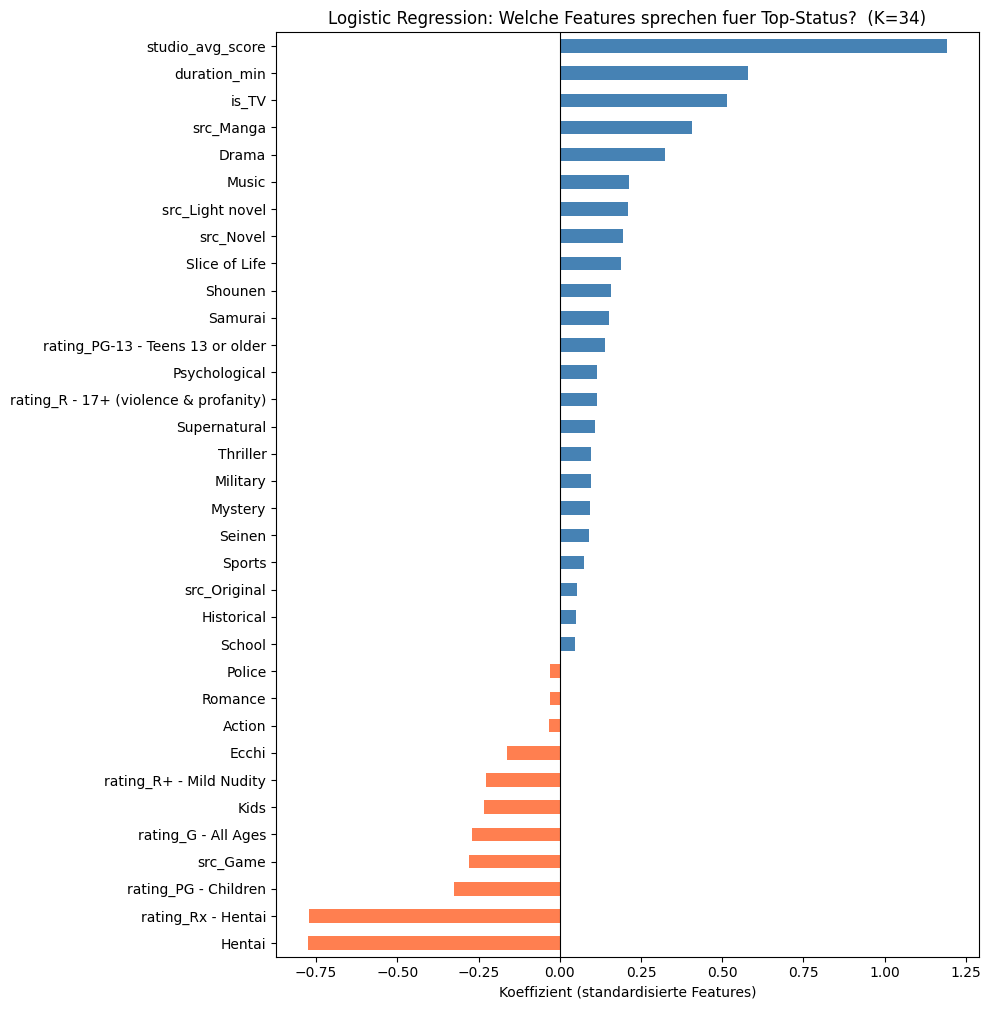

Top 5 Features fuer Top-Status:
Drama               0.325
src_Manga           0.406
is_TV               0.516
duration_min        0.579
studio_avg_score    1.191

Top 5 Features gegen Top-Status:
Hentai                 -0.775
rating_Rx - Hentai     -0.771
rating_PG - Children   -0.326
src_Game               -0.281
rating_G - All Ages    -0.271


In [25]:
selected_clf = X_train_c.columns[logreg_pipe.named_steps['select'].get_support()].tolist()
coefs = pd.Series(
    logreg_pipe.named_steps['model'].coef_[0],
    index=selected_clf,
).sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(coefs) * 0.30)))
colors = ['coral' if c < 0 else 'steelblue' for c in coefs]
coefs.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Logistic Regression: Welche Features sprechen fuer Top-Status?  (K={BEST_K_XGB})')
ax.set_xlabel('Koeffizient (standardisierte Features)')
plt.tight_layout()
plt.show()

print('Top 5 Features fuer Top-Status:')
print(coefs.tail(5).round(3).to_string())
print('\nTop 5 Features gegen Top-Status:')
print(coefs.head(5).round(3).to_string())

## 6. Ergebnisse & Fazit

### Regression — Score vorhersagen

| Modell | K | RMSE | MAE | R² | Hyperparameter |
|---|---|---|---|---|---|
| Lineare Regression (Baseline) | 40 | 0.636 | 0.499 | 0.489 | Defaults |
| Random Forest Regressor | 38 | 0.579 | 0.442 | 0.577 | Defaults |
| **XGBoost (GridSearchCV)** | **34** | **0.572** | **0.438** | **0.587** | `n_estimators=300, max_depth=7, learning_rate=0.05` |

**K-Sweep:** Jedes Modell hat sein eigenes Optimum: LR profitiert von allen verfügbaren Features (K=40), RF peakt knapp davor (K=38), XGB ist mit deutlich weniger Features (K=34) am besten — komplexere Modelle brauchen weniger lineare Vorab-Information.

**Tuning-Effekt:** GridSearchCV brachte bei LR 0 %, RF ~1 % (entfernt), XGB 1.53 % (behalten). **Feature-Engineering schlug Tuning klar:** allein `duration_min` brachte allen Modellen ~4 % besseres RMSE.

### Top-Analyse — Was macht einen Top-Anime aus?

**Slice-Performance:** Regression versagt auf Top-Subset (XGB RMSE 0.85, R² −9.3) — klassisches "regression to the mean", systematischer Bias −0.71.

**Klassifikator** (Logistic Regression balanced) erreicht **ROC-AUC 0.905**. Direkter Befund:

| Pro Top-Status | Koeffizient | | Gegen Top-Status | Koeffizient |
|---|---|---|---|---|
| `studio_avg_score` | +1.19 | | `Hentai` | −0.78 |
| `duration_min` | +0.58 | | `rating_Rx (Hentai)` | −0.77 |
| `is_TV` | +0.52 | | `rating_PG (Children)` | −0.33 |
| `src_Manga` | +0.41 | | `src_Game` | −0.28 |
| `Drama` | +0.33 | | `rating_G (All Ages)` | −0.27 |

### Zusammenfassung

- **Regression** ist gut für Score-Schätzung im Mittelfeld, versagt aber an der Spitze (Bias −0.7)
- **Top-Klassifikator** beantwortet direkter, was Top-Animes auszeichnet: Studio-Qualität + Duration + TV + Manga-Source + Drama
- **Größter Single-Hebel:** `duration_min` als Feature (~4 % RMSE-Reduktion)
- **Pipeline durchgängig:** `SelectKBest → StandardScaler → Modell`

Empfehlungssystem siehe `02_empfehlung.ipynb`.